# 02. Drzewo decyzyjne ręcznie: Gini „na piechotę”

Cel: przejść przez **pierwsze pełne drzewko klasyfikacyjne bez `sklearn`**.

Po tym ćwiczeniu student powinien umieć:

- policzyć Gini dla jednego węzła,
- policzyć ważone Gini po podziale,
- wybrać najlepsze pytanie,
- powtórzyć procedurę w kolejnej gałęzi,
- zakodować powstałe drzewo jako zwykłe `if/else`.

Dane są celowo małe. Każdy wiersz to jedna sytuacja: czy w takich warunkach kupujemy lody?


Ten notebook jest naturalną kontynuacją notebooka 01. Tam zobaczyliśmy gotowe drzewo i ideę Gini impurity, a tutaj odtwarzamy **pełny wybór splitów ręcznie**, krok po kroku.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook może działać na dwa sposoby:
# 1. z plikiem CSV w katalogu data/,
# 2. samodzielnie, dzięki małemu fallbackowi poniżej.
BASE = Path.cwd()
for candidate in [BASE, BASE.parent, Path("/mnt/data/drzewa_decyzyjne_dydaktyka")]:
    if (candidate / "data" / "05_lody_recznie.csv").exists():
        BASE = candidate
        break
else:
    BASE = Path.cwd()

ASSETS = BASE / "assets"
ASSETS.mkdir(exist_ok=True)

csv_path = BASE / "data" / "05_lody_recznie.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    # Fallback dydaktyczny zgodny z obliczeniami w markdownie:
    # 12 przykładów, 5 razy "tak", 7 razy "nie".
    df = pd.DataFrame({
        "id": range(1, 13),
        "cieplo":          [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
        "weekend":         [0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0],
        "krotka_kolejka":  [0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        "kup_lody":        ["nie", "nie", "nie", "nie", "nie", "tak", "tak", "tak", "tak", "tak", "nie", "nie"],
    })

df


,id,cieplo,weekend,krotka_kolejka,kup_lody
0,1,0,0,0,nie
1,2,0,0,1,nie
2,3,0,1,0,nie
3,4,0,1,1,nie
4,5,0,0,0,nie
5,6,1,0,1,tak
6,7,1,1,1,tak
7,8,1,0,1,tak
8,9,1,1,1,tak
9,10,1,1,0,tak


## 1. Odczytanie tabeli

Cechy są zapisane jako `0/1`:

| Cecha | `1` oznacza | `0` oznacza |
|---|---|---|
| `cieplo` | jest ciepło | nie jest ciepło |
| `weekend` | jest weekend | dzień roboczy |
| `krotka_kolejka` | kolejka jest krótka | kolejka jest długa |

Zmienna docelowa to `kup_lody`: `tak` albo `nie`.


## 2. Gini dla węzła rodzica

Wzór:

```text
Gini = 1 - suma(p_k^2)
```

gdzie `p_k` to udział klasy `k` w danym węźle.

W całej tabeli mamy:

```text
kup_lody = tak: 5 przykładów
kup_lody = nie: 7 przykładów
razem: 12 przykładów
```

Czyli:

```text
Gini(rodzic) = 1 - (5/12)^2 - (7/12)^2
              = 1 - 25/144 - 49/144
              = 70/144
              = 0.486
```

Im większe Gini, tym bardziej wymieszane klasy. Gini równe `0` oznacza czysty węzeł, czyli tylko jedną klasę.


In [2]:
counts = df["kup_lody"].value_counts()
parent_gini_manual = 1 - (counts["tak"] / len(df))**2 - (counts["nie"] / len(df))**2

print(counts)
print("Gini rodzica:", round(parent_gini_manual, 3))


kup_lody
nie    7
tak    5
Name: count, dtype: int64
Gini rodzica: 0.486


## 3. Funkcja do liczenia Gini

Najpierw zapisujemy to, co przed chwilą policzyliśmy na tablicy.


In [3]:
def gini(labels):
    """Gini dla serii etykiet, np. ['tak', 'nie', 'tak']."""
    proportions = labels.value_counts(normalize=True)
    return 1 - np.sum(proportions ** 2)

print("Gini rodzica z funkcji:", round(gini(df["kup_lody"]), 3))


Gini rodzica z funkcji: 0.486


## 4. Pierwszy kandydat: podział po `cieplo`

Pytanie brzmi:

```text
Czy cieplo == 1?
```

Dostajemy dwa dzieci:

| Gałąź | Liczba przykładów | Klasy | Gini |
|---|---:|---|---:|
| `cieplo = 0` | 5 | 0 × `tak`, 5 × `nie` | `0.000` |
| `cieplo = 1` | 7 | 5 × `tak`, 2 × `nie` | `1 - (5/7)^2 - (2/7)^2 = 0.408` |

Ważone Gini po podziale:

```text
Gini_po_podziale = (5/12) * 0.000 + (7/12) * 0.408
                 = 0.238
```

Zysk Giniego:

```text
zysk = Gini_rodzica - Gini_po_podziale
     = 0.486 - 0.238
     = 0.248
```


In [4]:
def split_score(data, feature, target="kup_lody"):
    """Zwraca ważone Gini po podziale i szczegóły dla każdej gałęzi."""
    n_total = len(data)
    weighted_gini = 0
    rows = []

    for value, part in data.groupby(feature):
        part_gini = gini(part[target])
        weight = len(part) / n_total
        weighted_gini += weight * part_gini
        rows.append({
            "cecha": feature,
            "wartosc": value,
            "liczba_wierszy": len(part),
            "klasy": dict(part[target].value_counts()),
            "gini_dziecka": round(part_gini, 3),
            "waga": round(weight, 3),
        })

    return weighted_gini, pd.DataFrame(rows)

score_cieplo, details_cieplo = split_score(df, "cieplo")
print("Ważone Gini po podziale po 'cieplo':", round(score_cieplo, 3))
details_cieplo


Ważone Gini po podziale po 'cieplo': 0.238


,cecha,wartosc,liczba_wierszy,klasy,gini_dziecka,waga
0,cieplo,0,5,{'nie': 5},0.000,0.417
1,cieplo,1,7,"{'tak': 5, 'nie': 2}",0.408,0.583


## 5. Porównanie wszystkich pierwszych pytań

Teraz robimy to samo dla trzech możliwych pytań.


In [5]:
features = ["cieplo", "weekend", "krotka_kolejka"]
parent_gini = gini(df["kup_lody"])

rows = []
for feature in features:
    score, _ = split_score(df, feature)
    rows.append({
        "pytanie": f"{feature} == 1?",
        "gini_po_podziale": round(score, 3),
        "zysk_gini": round(parent_gini - score, 3),
    })

pd.DataFrame(rows).sort_values("gini_po_podziale")


,pytanie,gini_po_podziale,zysk_gini
0,cieplo == 1?,0.238,0.248
2,krotka_kolejka == 1?,0.361,0.125
1,weekend == 1?,0.438,0.048


Najlepsze pierwsze pytanie to to z **najmniejszym Gini po podziale** albo równoważnie z **największym zyskiem Giniego**.

Tutaj wygrywa:

```text
Czy cieplo == 1?
```

Pierwsza reguła drzewa:

```text
jeżeli cieplo == 0 -> kup_lody = nie
jeżeli cieplo == 1 -> trzeba pytać dalej
```


## 6. Drugi poziom: pracujemy tylko w gałęzi `cieplo == 1`

Drzewa działają rekurencyjnie: po wybraniu pierwszego pytania powtarzamy ten sam proces w każdej nieczystej gałęzi.

W gałęzi `cieplo == 0` mamy same `nie`, więc ta gałąź jest już liściem.

W gałęzi `cieplo == 1` mamy mieszankę klas, więc liczymy dalej.


In [6]:
warm = df[df["cieplo"] == 1].copy()
warm


,id,cieplo,weekend,krotka_kolejka,kup_lody
5,6,1,0,1,tak
6,7,1,1,1,tak
7,8,1,0,1,tak
8,9,1,1,1,tak
9,10,1,1,0,tak
10,11,1,0,0,nie
11,12,1,0,0,nie


In [7]:
parent_warm = gini(warm["kup_lody"])

rows = []
for feature in ["weekend", "krotka_kolejka"]:
    score, _ = split_score(warm, feature)
    rows.append({
        "pytanie": f"{feature} == 1?",
        "gini_po_podziale": round(score, 3),
        "zysk_gini": round(parent_warm - score, 3),
    })

pd.DataFrame(rows).sort_values("gini_po_podziale")


,pytanie,gini_po_podziale,zysk_gini
1,krotka_kolejka == 1?,0.190,0.218
0,weekend == 1?,0.286,0.122


W gałęzi `cieplo == 1` najlepsze pytanie to:

```text
Czy krotka_kolejka == 1?
```

Reguły po dwóch poziomach:

```text
jeżeli cieplo == 0 -> nie
jeżeli cieplo == 1 i krotka_kolejka == 1 -> tak
jeżeli cieplo == 1 i krotka_kolejka == 0 -> trzeba pytać dalej
```


## 7. Trzeci poziom: ostatnia nieczysta gałąź

Zostaje gałąź:

```text
cieplo == 1 oraz krotka_kolejka == 0
```


In [8]:
branch = df[(df["cieplo"] == 1) & (df["krotka_kolejka"] == 0)].copy()
branch


,id,cieplo,weekend,krotka_kolejka,kup_lody
9,10,1,1,0,tak
10,11,1,0,0,nie
11,12,1,0,0,nie


In [9]:
score_weekend, details_weekend = split_score(branch, "weekend")
print("Gini przed podziałem:", round(gini(branch["kup_lody"]), 3))
print("Gini po podziale po 'weekend':", round(score_weekend, 3))
details_weekend


Gini przed podziałem: 0.444
Gini po podziale po 'weekend': 0.0


,cecha,wartosc,liczba_wierszy,klasy,gini_dziecka,waga
0,weekend,0,2,{'nie': 2},0.0,0.667
1,weekend,1,1,{'tak': 1},0.0,0.333


Po pytaniu `weekend == 1?` oba dzieci są czyste, więc kończymy.

Ostateczne drzewo:

```text
Czy cieplo == 1?
├── nie -> kup_lody = nie
└── tak:
    Czy krotka_kolejka == 1?
    ├── tak -> kup_lody = tak
    └── nie:
        Czy weekend == 1?
        ├── tak -> kup_lody = tak
        └── nie -> kup_lody = nie
```


## 8. Kodujemy drzewo jako zwykłe `if/else`

To jest najprostsza możliwa implementacja drzewa: żadnego uczenia, tylko reguły, które przed chwilą wyprowadziliśmy ręcznie.


In [10]:
def predict_lody_manual(row):
    if row["cieplo"] == 0:
        return "nie"

    # Od tego miejsca wiemy, że cieplo == 1.
    if row["krotka_kolejka"] == 1:
        return "tak"

    # Od tego miejsca wiemy, że cieplo == 1 oraz krotka_kolejka == 0.
    if row["weekend"] == 1:
        return "tak"

    return "nie"

wynik = df.copy()
wynik["pred_manual"] = wynik.apply(predict_lody_manual, axis=1)
wynik["czy_poprawnie"] = wynik["kup_lody"] == wynik["pred_manual"]
wynik


,id,cieplo,weekend,krotka_kolejka,kup_lody,pred_manual,czy_poprawnie
0,1,0,0,0,nie,nie,True
1,2,0,0,1,nie,nie,True
2,3,0,1,0,nie,nie,True
3,4,0,1,1,nie,nie,True
4,5,0,0,0,nie,nie,True
5,6,1,0,1,tak,tak,True
6,7,1,1,1,tak,tak,True
7,8,1,0,1,tak,tak,True
8,9,1,1,1,tak,tak,True
9,10,1,1,0,tak,tak,True


In [11]:
accuracy = wynik["czy_poprawnie"].mean()
print(f"Trafność ręcznego drzewa na tych danych: {accuracy:.0%}")


Trafność ręcznego drzewa na tych danych: 100%


## 9. Prosta wizualizacja drzewa

Poniższy kod rysuje drzewo, które zbudowaliśmy na piechotę. Obraz zapisuje się też do katalogu `assets/`.


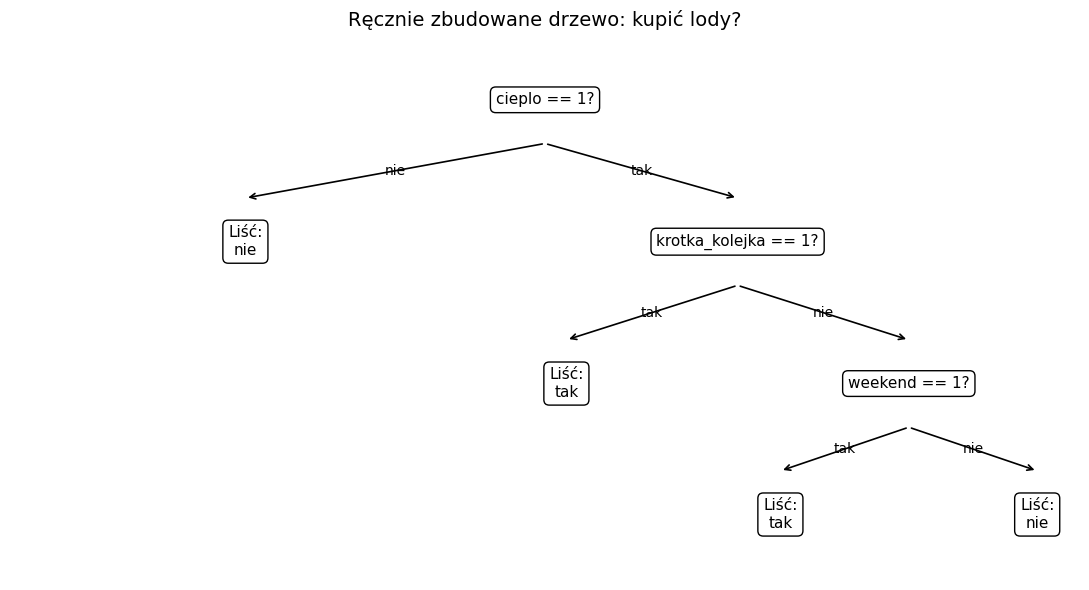

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.axis("off")

def add_box(x, y, text):
    ax.text(
        x, y, text,
        ha="center", va="center", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black")
    )

def add_arrow(x1, y1, x2, y2, label):
    ax.annotate(
        "", xy=(x2, y2 + 0.08), xytext=(x1, y1 - 0.08),
        arrowprops=dict(arrowstyle="->", lw=1.2)
    )
    ax.text((x1 + x2) / 2, (y1 + y2) / 2, label, ha="center", va="center", fontsize=10)

add_box(0.50, 0.88, "cieplo == 1?")
add_box(0.22, 0.62, "Liść:\nnie")
add_box(0.68, 0.62, "krotka_kolejka == 1?")
add_box(0.52, 0.36, "Liść:\ntak")
add_box(0.84, 0.36, "weekend == 1?")
add_box(0.72, 0.12, "Liść:\ntak")
add_box(0.96, 0.12, "Liść:\nnie")

add_arrow(0.50, 0.88, 0.22, 0.62, "nie")
add_arrow(0.50, 0.88, 0.68, 0.62, "tak")
add_arrow(0.68, 0.62, 0.52, 0.36, "tak")
add_arrow(0.68, 0.62, 0.84, 0.36, "nie")
add_arrow(0.84, 0.36, 0.72, 0.12, "tak")
add_arrow(0.84, 0.36, 0.96, 0.12, "nie")

ax.set_title("Ręcznie zbudowane drzewo: kupić lody?", fontsize=14)
plt.tight_layout()
plt.savefig(ASSETS / "02_drzewo_reczne_gini.png", dpi=160, bbox_inches="tight")
plt.show()


## 10. Zadania dla studentów

1. Zmień etykietę w jednym wierszu i sprawdź, czy pierwsze pytanie nadal jest najlepsze.
2. Zbuduj wersję drzewa o maksymalnej głębokości `2`. Ile przykładów będzie błędnie sklasyfikowanych?
3. Dopisz funkcję, która dla każdego liścia pokazuje nie tylko decyzję, ale też liczbę przykładów w liściu.
4. Policz ręcznie Gini dla podziału po `krotka_kolejka` w całym zbiorze i porównaj z wynikiem z kodu.
